In [44]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

def scat(x, y, c,marker):
    return ax.scatter(x, y*100, c=c, ls='-', cmap=cmap, norm=norm, s=30, marker=marker
                     )
import pyccl as ccl
import sys
sys.path.append('../forecasts/')

sys.path.append('../survey_design/')
import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
import pickle
def save_pickle(dat, filename, **kwargs):
    file = open(filename,'wb')
    pickle.dump(dat, file)
    file.close()
def load(filename, **kwargs):
    with open(filename, 'rb') as fin:
        return pickle.load(fin, **kwargs)

In [46]:
path = '../survey_design/telescope_and_science_metrics/'

In [47]:
survey_design_bright = load(path + 'survey_design_Bright.pkl')
survey_design_grey = load(path + 'survey_design_Grey.pkl')
survey_design_grey_MagMax = load(path + 'survey_design_Grey_MagMax.pkl')
#survey_design_dark = load(path + 'survey_design_Dark.pkl')

In [54]:
survey_design_grey_MagMax['config_survey'].keys()

dict_keys(['survey_type', 'N_fibres', 'S_FoV', 'S_survey', 'exposure_time', 'observation_fraction', 'tracer_N_zm_file', 'tracers', 'color', 'MagMax_target_density', 'MagMax_spec_density', 'MagMax_spec_redshift_density', 'MagMax_target_redshift_density', 'MagMax_target_pointings', 'MagMax_fibre_time', 'MagMax_calendar_time', 'MagMax_mag_centers', 'MagMax_redshift_centers', 'MagMax_lowz_target_density', 'MagMax_lowz_spec_density', 'MagMax_lowz_spec_redshift_density', 'MagMax_lowz_target_redshift_density', 'MagMax_lowz_target_pointings', 'MagMax_lowz_fibre_time', 'MagMax_lowz_calendar_time', 'MagMax_lowz_mag_centers', 'MagMax_lowz_redshift_centers', 'MagMax_midz_target_density', 'MagMax_midz_spec_density', 'MagMax_midz_spec_redshift_density', 'MagMax_midz_target_redshift_density', 'MagMax_midz_target_pointings', 'MagMax_midz_fibre_time', 'MagMax_midz_calendar_time', 'MagMax_midz_mag_centers', 'MagMax_midz_redshift_centers', 'MagMax_highz_target_density', 'MagMax_highz_spec_density', 'MagM

BG_bright = 2905.251641137855
BG_faint = 4250.929978118162
LRG = 2508.807439824945
ELG = 16491.65827385383
26156.647332934794
MagMax = 28297.02380952381


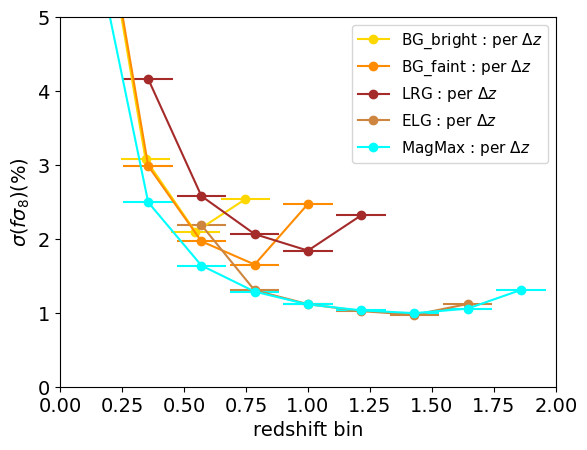

In [55]:
n=0
for k, tracer in enumerate(['BG_bright', 'BG_faint', 'LRG','ELG', 'MagMax']):
    
    survey = survey_design_grey
    if tracer == 'BG_bright':
        survey = survey_design_bright
        i =8
        #plt.errorbar(survey_design_bright['per_tracer_forecasts'][tracer+'_list_zbin_rsd'][i], survey_design_bright['per_tracer_forecasts'][tracer+'_list_sigma_rsd'][i], xerr=0.1)
    if tracer == 'BG_faint':
        survey = survey_design_grey
        i=3

    if tracer == 'LRG':
        survey = survey_design_grey
        i=12 #22.8

    if tracer == 'ELG':
        survey = survey_design_grey
        i=8 #25.3

    if tracer == 'MagMax':
        survey = survey_design_grey_MagMax
        i=11

    if tracer!='MagMax':
        n+=survey['config_survey'][tracer+'_target_density'][i]

    if tracer=='MagMax': 
        print(n)
    
    print(tracer, '=', survey['config_survey'][tracer+'_target_density'][i])

    mask_color = np.array(survey['config_survey']['tracers'])==tracer
   
    color = np.array(survey['config_survey']['color'])[mask_color][0]

    #print(survey['config_survey'][tracer+'_spec_density'][i])
    x, y = survey['per_tracer_forecasts'][tracer+'_list_zbin_rsd'][i], 100*np.array(survey['per_tracer_forecasts'][tracer+'_list_sigma_rsd'][i])
    plt.errorbar(np.array(x)[y < 10], np.array(y)[y < 10], xerr=0.1, label = tracer+r' : per $\Delta z$',
                 color = color, 
                 marker='o', fmt='-')


            
        #plt.plot(np.array(x)[y < 10], np.array(y)[y < 10],
                     #color = color, 
                     #marker='x',)
        

    plt.xlim(0, 2)
    plt.ylim(0, 5)
plt.ylabel(r'$\sigma(f\sigma_8) (\%)$', fontsize=14)
plt.xlabel(r'redshift bin', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=11)

BG_bright = 2905.251641137855
BG_faint = 4250.929978118162
LRG = 2508.807439824945
ELG = 16491.65827385383
MagMax_lowz = 28297.02380952381
MagMax_midz = 28297.02380952381
MagMax_highz = 28297.02380952381


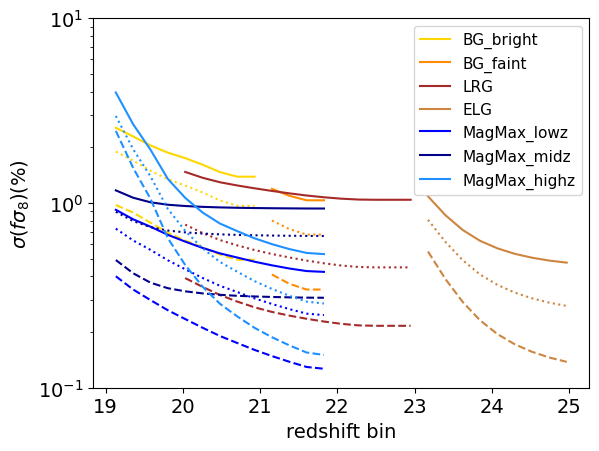

In [73]:
n=0
for k, tracer in enumerate(['BG_bright', 'BG_faint', 'LRG','ELG', 'MagMax_lowz','MagMax_midz','MagMax_highz']):
    
    survey = survey_design_grey
    if tracer == 'BG_bright':
        survey = survey_design_bright
        i =8
        #plt.errorbar(survey_design_bright['per_tracer_forecasts'][tracer+'_list_zbin_rsd'][i], survey_design_bright['per_tracer_forecasts'][tracer+'_list_sigma_rsd'][i], xerr=0.1)
    if tracer == 'BG_faint':
        survey = survey_design_grey
        i=3

    if tracer == 'LRG':
        survey = survey_design_grey
        i=12 #22.8

    if tracer == 'ELG':
        survey = survey_design_grey
        i=8 #25.3

    if 'MagMax' in tracer.split('_'):
        survey = survey_design_grey_MagMax
        i=11

    if tracer!='MagMax':
        n+=survey['config_survey'][tracer+'_target_density'][i]

    if tracer=='MagMax': 
        print(n)
    
    print(tracer, '=', survey['config_survey'][tracer+'_target_density'][i])

    mask_color = np.array(survey['config_survey']['tracers'])==tracer
   
    color = np.array(survey['config_survey']['color'])[mask_color][0]

    x, y = survey['config_survey'][tracer+'_mag_centers'], 100*np.array(survey['per_tracer_forecasts'][tracer+'_sigma_rsd_eff'])
    plt.plot(np.array(x)[y < 100], np.array(y)[y < 100],
                 color = color, 
                 marker='',label = tracer)
    #plt.fill_between(np.array(x), np.array(y), 0*np.array(y),  color=color, alpha=0.4)

    x, y = survey['config_survey'][tracer+'_mag_centers'], 100*np.array(survey['per_tracer_forecasts'][tracer+'_sigma_Da_eff'])
    plt.plot(np.array(x)[y < 100], np.array(y)[y < 100],
                 color = color, 
                 marker='', ls='--')
    #plt.fill_between(np.array(x), np.array(y), 0*np.array(y),  color=color, alpha=0.4)

    x, y = survey['config_survey'][tracer+'_mag_centers'], 100*np.array(survey['per_tracer_forecasts'][tracer+'_sigma_H_eff'])
    plt.plot(np.array(x)[y < 10], np.array(y)[y < 10],
                 color = color, 
                 marker='', ls=':')
    #plt.fill_between(np.array(x), np.array(y), 0*np.array(y),  color=color, alpha=0.4)

            
        #plt.plot(np.array(x)[y < 10], np.array(y)[y < 10],
                     #color = color, 
                     #marker='x',)
        

    #plt.xlim(0, 1.3)
    plt.ylim(0.1, 10)
plt.ylabel(r'$\sigma(f\sigma_8) (\%)$', fontsize=14)
plt.xlabel(r'redshift bin', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.yscale('log')
plt.legend(fontsize=11)